# Food Detection Dataset Analysis

This notebook performs exploratory data analysis (EDA) on the food detection datasets used for training the NutriVision food detection model.

The following datasets are analyzed:

1. IndianFood10 – Primary detection dataset
2. IndianFoodNet-30 – Extended dataset with additional food categories
3. South Indian Food Detection Dataset – Dataset containing additional South Indian dishes

The objective of this analysis is to understand dataset characteristics, verify annotation quality, and prepare the data for ingestion into the YOLO object detection pipeline.

## Download Datasets from Roboflow

In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 39.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="API_KEY")

### Download IndianFood10 Dataset

In [3]:
project1 = rf.workspace("fooddetection-xtlhp").project("indianfood10")
dataset1 = project1.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to indianfood10-1 in yolov8:: 100%|██████████| 23010/23010 [00:05<00:00, 4282.00it/s]


### Download IndianFoodNet-30 Dataset

In [4]:
project2 = rf.workspace("indianfoodnet").project("indianfoodnet")
dataset2 = project2.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to IndianFoodNet-1 in yolov8:: 100%|██████████| 26084/26084 [00:07<00:00, 3551.63it/s]


### Download South Indian Food Detection Dataset

In [5]:
project3 = rf.workspace("south-indian-food-detection-and-classification").project("food-detection-nlusn")
dataset3 = project3.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FOOD-DETECTION-1 in yolov8:: 100%|██████████| 16034/16034 [00:03<00:00, 5078.07it/s]


## Dataset Structure Verification

Each dataset downloaded from Roboflow follows the YOLO dataset structure:



In [6]:
import os

dataset_paths = [
    "/content/indianfood10-1",
    "/content/IndianFoodNet-1",
    "/content/FOOD-DETECTION-1"
]

for path in dataset_paths:
    print(path)
    print(os.listdir(path))

/content/indianfood10-1
['test', 'README.dataset.txt', 'README.roboflow.txt', 'train', 'data.yaml', 'valid']
/content/IndianFoodNet-1
['test', 'README.dataset.txt', 'README.roboflow.txt', 'train', 'data.yaml', 'valid']
/content/FOOD-DETECTION-1
['test', 'README.dataset.txt', 'README.roboflow.txt', 'train', 'data.yaml', 'valid']


## Dataset Statistics

In [7]:
def count_images(dataset_path):

    train = len(os.listdir(dataset_path + "/train/images"))
    valid = len(os.listdir(dataset_path + "/valid/images"))
    test = len(os.listdir(dataset_path + "/test/images"))

    return train, valid, test

In [8]:
for path in dataset_paths:

    train, val, test = count_images(path)

    print("Dataset:", path)
    print("Train:", train)
    print("Validation:", val)
    print("Test:", test)
    print()

Dataset: /content/indianfood10-1
Train: 9199
Validation: 1726
Test: 574

Dataset: /content/IndianFoodNet-1
Train: 11387
Validation: 1073
Test: 576

Dataset: /content/FOOD-DETECTION-1
Train: 6404
Validation: 812
Test: 795



Sample  multi-dish plate images with YOLO segmentation mask annotations

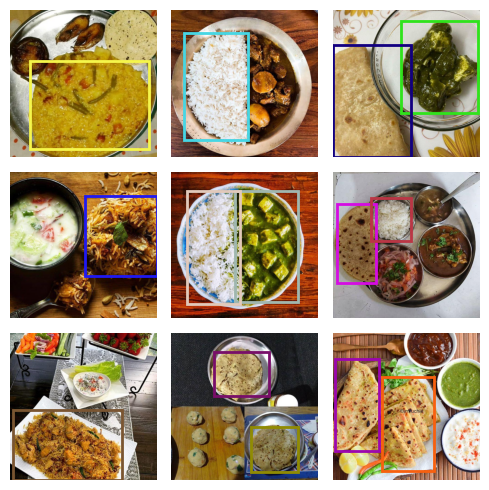

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

image_dir = "/content/indianfood10-1/train/images"
label_dir = "/content/indianfood10-1/train/labels"

image_files = os.listdir(image_dir)
sample_images = random.sample(image_files, 9)

fig, axes = plt.subplots(3,3, figsize=(5,5))

for ax, img_file in zip(axes.flatten(), sample_images):

    img_path = os.path.join(image_dir, img_file)
    label_path = os.path.join(label_dir, img_file.replace(".jpg",".txt").replace(".png",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:
            data = list(map(float, line.split()))
            cls = int(data[0])
            bbox = data[1:]

            x = bbox[0] * w
            y = bbox[1] * h
            bw = bbox[2] * w
            bh = bbox[3] * h

            x1 = int(x - bw/2)
            y1 = int(y - bh/2)

            rect = plt.Rectangle((x1,y1), bw, bh,
                                 linewidth=2,
                                 edgecolor=np.random.rand(3,),
                                 facecolor='none')

            ax.add_patch(rect)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Distribution of number of foods per plate image (2 foods, 3 foods, 4+ foods)

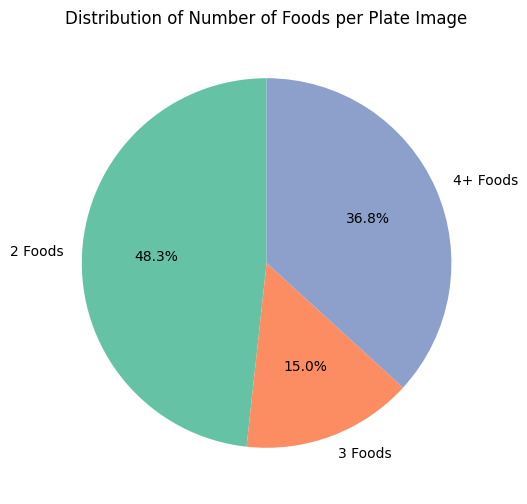

In [10]:
import os
import matplotlib.pyplot as plt

label_dir = "/content/indianfood10-1/train/labels"

food_counts = []

for file in os.listdir(label_dir):
    with open(os.path.join(label_dir, file)) as f:
        lines = f.readlines()
    food_counts.append(len(lines))

two_foods = sum(1 for x in food_counts if x == 2)
three_foods = sum(1 for x in food_counts if x == 3)
four_plus = sum(1 for x in food_counts if x >= 4)

sizes = [two_foods, three_foods, four_plus]
labels = ["2 Foods", "3 Foods", "4+ Foods"]

colors = ["#66c2a5", "#fc8d62", "#8da0cb"]

plt.figure(figsize=(6,6))
plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Distribution of Number of Foods per Plate Image")

plt.show()

Four examples of annotation quality issues — loose boxes, missing label, edge truncation

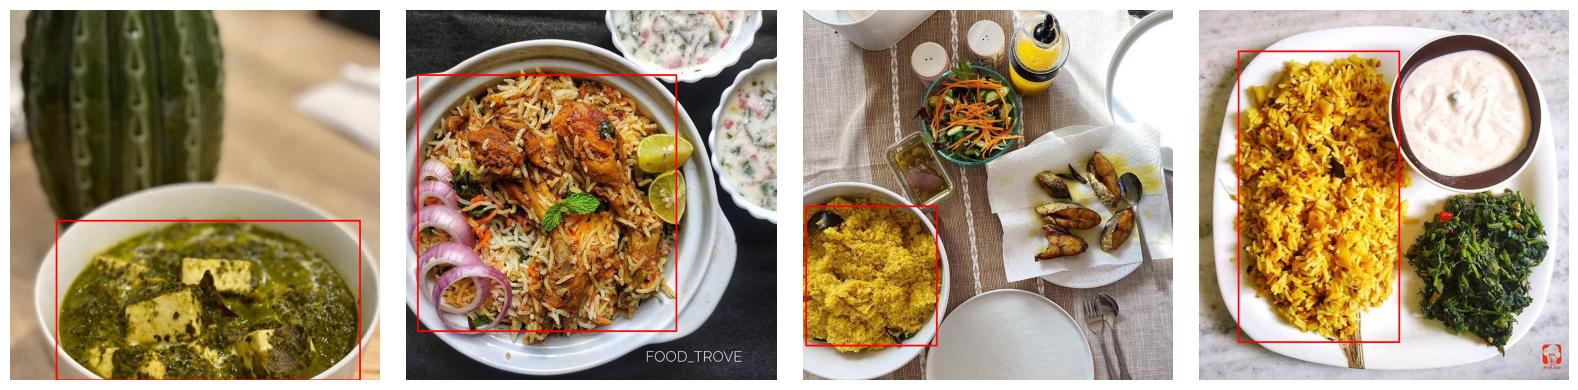

In [32]:
import os
import cv2
import random
import matplotlib.pyplot as plt

image_dir = "/content/indianfood10-1/train/images"
label_dir = "/content/indianfood10-1/train/labels"

image_files = os.listdir(image_dir)
sample_images = random.sample(image_files, 4)

fig, axes = plt.subplots(1,4, figsize=(16,4))

for ax, img_file in zip(axes, sample_images):

    img_path = os.path.join(image_dir, img_file)
    label_path = os.path.join(label_dir, img_file.replace(".jpg",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:
            cls, x, y, bw, bh = map(float, line.split())

            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            bw = int(bw * w)
            bh = int(bh * h)

            cv2.rectangle(img,(x1,y1),(x1+bw,y1+bh),(255,0,0),2)

    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

Image count per class across all 30 categories — IndianFoodNet-30, sorted descending


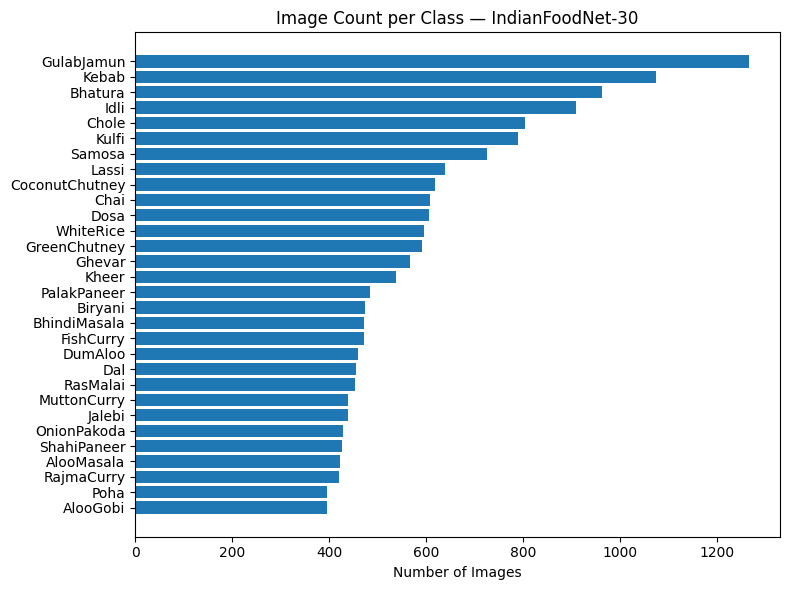

In [12]:
import os
import yaml
from collections import Counter
import matplotlib.pyplot as plt

dataset_path = "/content/IndianFoodNet-1"
label_dir = dataset_path + "/train/labels"

with open(dataset_path + "/data.yaml", "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

class_counts = Counter()

for file in os.listdir(label_dir):

    with open(os.path.join(label_dir, file)) as f:
        lines = f.readlines()

    for line in lines:
        class_id = int(line.split()[0])
        class_counts[class_id] += 1

counts = {class_names[k]: v for k, v in class_counts.items()}
counts_sorted = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

labels = list(counts_sorted.keys())
values = list(counts_sorted.values())
plt.figure(figsize=(8,6))
plt.barh(labels, values)
plt.gca().invert_yaxis()

plt.xlabel("Number of Images")
plt.title("Image Count per Class — IndianFoodNet-30")

plt.tight_layout()
plt.show()

Bounding box width vs height distribution across 30 classes — shows shape diversity


## Class Distribution Analysis

In [14]:
import yaml

def get_classes(dataset_path):

    with open(dataset_path + "/data.yaml") as f:
        data = yaml.safe_load(f)

    return data["names"]

In [15]:
for path in dataset_paths:

    classes = get_classes(path)

    print("Dataset:", path)
    print("Number of classes:", len(classes))
    print(classes)
    print()

Dataset: /content/indianfood10-1
Number of classes: 10
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Dataset: /content/IndianFoodNet-1
Number of classes: 30
['AlooGobi', 'AlooMasala', 'Bhatura', 'BhindiMasala', 'Biryani', 'Chai', 'Chole', 'CoconutChutney', 'Dal', 'Dosa', 'DumAloo', 'FishCurry', 'Ghevar', 'GreenChutney', 'GulabJamun', 'Idli', 'Jalebi', 'Kebab', 'Kheer', 'Kulfi', 'Lassi', 'MuttonCurry', 'OnionPakoda', 'PalakPaneer', 'Poha', 'RajmaCurry', 'RasMalai', 'Samosa', 'ShahiPaneer', 'WhiteRice']

Dataset: /content/FOOD-DETECTION-1
Number of classes: 31
['Appam', 'Beetroot poriyal', 'Boiled Egg', 'Carrot poriyal', 'Chicken 65', 'Chicken briyani', 'Dosa', 'Idly', 'Kaara chutney', 'Kali', 'Koozh', 'Lemon Rice', 'Mushroom briyani', 'Mutton Briyani', 'Nandu masala', 'Nei satham', 'Paal kolukattai', 'Paneer briyani', 'Panner masala', 'Parupu vada', 'Pidi kolukattai', 'Poorna kolukattai', 'Prawn thokku', 'Puthina Chutney', 'Sambar', 'Sambar satham', 'Satham', 'Thengai chutney', 'U

## Bounding Box Annotation Analysis

In [16]:
def count_annotations(dataset_path):

    label_path = dataset_path + "/train/labels"

    total_boxes = 0

    for file in os.listdir(label_path):

        with open(os.path.join(label_path,file)) as f:
            lines = f.readlines()
            total_boxes += len(lines)

    return total_boxes

In [17]:
for path in dataset_paths:

    boxes = count_annotations(path)

    print("Dataset:", path)
    print("Total bounding boxes:", boxes)

Dataset: /content/indianfood10-1
Total bounding boxes: 16922
Dataset: /content/IndianFoodNet-1
Total bounding boxes: 17924
Dataset: /content/FOOD-DETECTION-1
Total bounding boxes: 6438


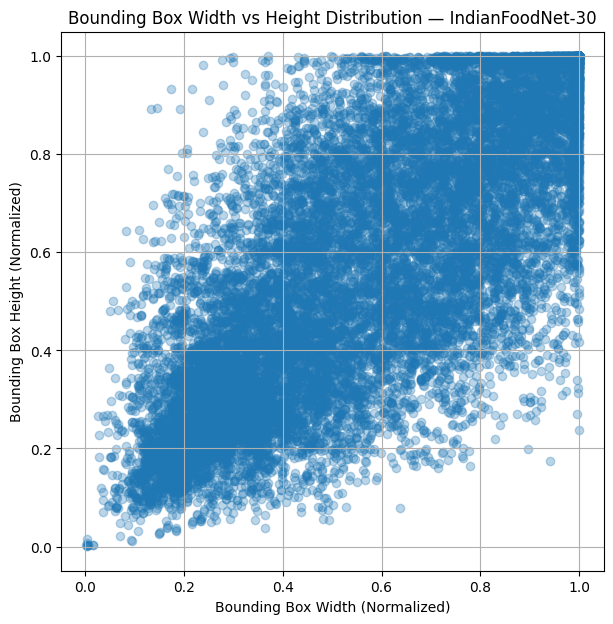

In [13]:
import os
import matplotlib.pyplot as plt

label_dir = "/content/IndianFoodNet-1/train/labels"

widths = []
heights = []

for file in os.listdir(label_dir):

    with open(os.path.join(label_dir, file)) as f:
        lines = f.readlines()

    for line in lines:
        cls, x, y, w, h = map(float, line.split())

        widths.append(w)
        heights.append(h)

plt.figure(figsize=(7,7))

plt.scatter(widths, heights, alpha=0.3)

plt.xlabel("Bounding Box Width (Normalized)")
plt.ylabel("Bounding Box Height (Normalized)")
plt.title("Bounding Box Width vs Height Distribution — IndianFoodNet-30")

plt.grid(True)

plt.show()

## Image Resolution Analysis

In [18]:
import cv2
import matplotlib.pyplot as plt

widths = []
heights = []

dataset_path = "/content/indianfood10-1/train/images"

for img in os.listdir(dataset_path)[:500]:

    image = cv2.imread(os.path.join(dataset_path,img))

    h,w,_ = image.shape

    widths.append(w)
    heights.append(h)

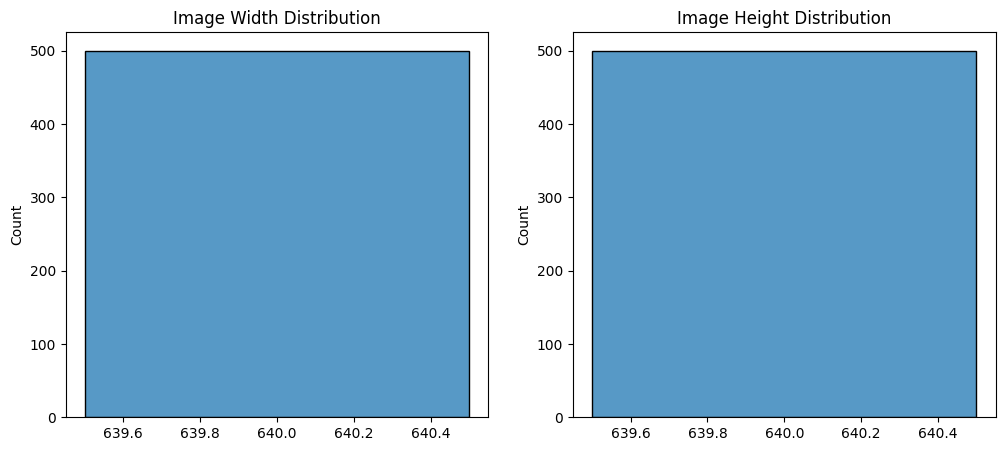

In [19]:
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(widths)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(heights)
plt.title("Image Height Distribution")

plt.show()

## Dataset Quality Checks

In [20]:
corrupted = []

for img in os.listdir(dataset_path):

    path = os.path.join(dataset_path,img)

    try:
        image = cv2.imread(path)

        if image is None:
            corrupted.append(path)

    except:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


## Sample Image and Annotation Visualization

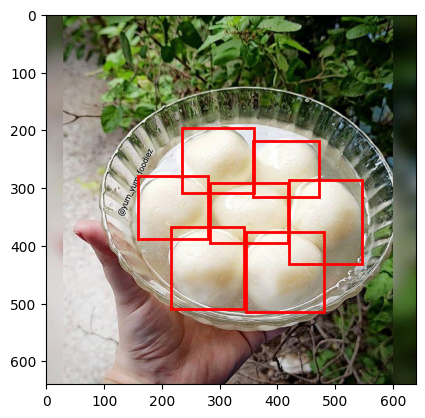

In [21]:
import matplotlib.patches as patches
import random

img_file = random.choice(os.listdir(dataset_path))

img_path = os.path.join(dataset_path,img_file)
label_path = img_path.replace("images","labels").replace(".jpg",".txt")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h,w,_ = img.shape

fig,ax = plt.subplots(1)
ax.imshow(img)

with open(label_path) as f:

    for line in f:

        cls,x,y,bw,bh = map(float,line.split())

        x1 = int((x-bw/2)*w)
        y1 = int((y-bh/2)*h)
        x2 = int((x+bw/2)*w)
        y2 = int((y+bh/2)*h)

        rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                 linewidth=2,
                                 edgecolor="red",
                                 facecolor="none")

        ax.add_patch(rect)

plt.show()

## Dataset Size Comparison

This visualization compares the size of the three detection datasets used in the project. The comparison helps understand the contribution of each dataset to the overall training data.

Dataset: indianfood10-1
Train: 9199
Validation: 1726
Test: 574
Total: 11499

Dataset: IndianFoodNet-1
Train: 11387
Validation: 1073
Test: 576
Total: 13036

Dataset: FOOD-DETECTION-1
Train: 6404
Validation: 812
Test: 795
Total: 8011



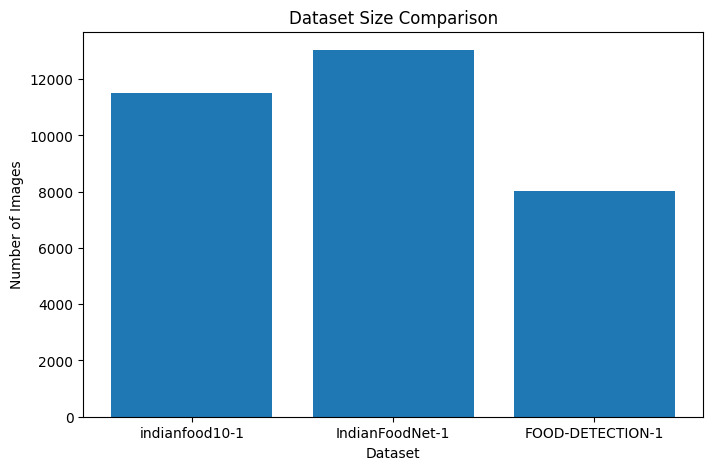

In [22]:
dataset_names = []
dataset_sizes = []

for path in dataset_paths:

    train, val, test = count_images(path)

    name = path.split("/")[-1]

    total = train + val + test

    dataset_names.append(name)
    dataset_sizes.append(total)

    print("Dataset:", name)
    print("Train:", train)
    print("Validation:", val)
    print("Test:", test)
    print("Total:", total)
    print()

plt.figure(figsize=(8,5))
plt.bar(dataset_names, dataset_sizes)

plt.title("Dataset Size Comparison")
plt.ylabel("Number of Images")
plt.xlabel("Dataset")

plt.show()

## Bounding Box Distribution Across Datasets

This analysis compares the number of annotated bounding boxes in each dataset. Bounding boxes represent labeled food objects used for training the object detection model.

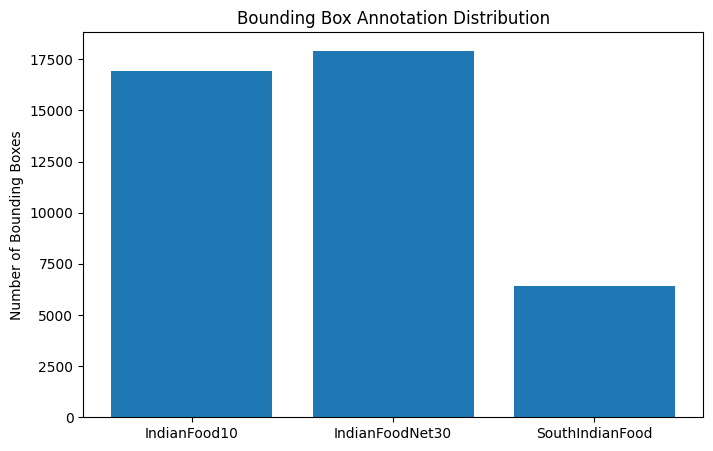

In [23]:
datasets = ["IndianFood10", "IndianFoodNet30", "SouthIndianFood"]
boxes = [16922, 17924, 6438]

plt.figure(figsize=(8,5))

plt.bar(datasets, boxes)

plt.title("Bounding Box Annotation Distribution")
plt.ylabel("Number of Bounding Boxes")

plt.show()

## Bounding Box Density Analysis

This analysis measures the average number of annotated objects per image. It helps understand whether images contain single or multiple food items.

In [24]:
def bbox_per_image(dataset_path):

    label_path = dataset_path + "/train/labels"

    counts = []

    for file in os.listdir(label_path):

        with open(os.path.join(label_path,file)) as f:

            lines = f.readlines()

            counts.append(len(lines))

    return counts

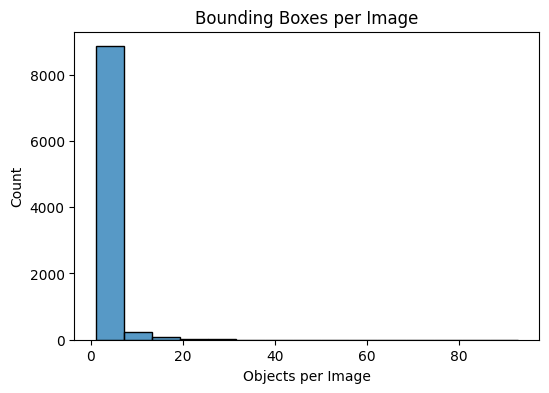

In [25]:
counts = bbox_per_image("/content/indianfood10-1")

import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(counts)

plt.title("Bounding Boxes per Image")
plt.xlabel("Objects per Image")

plt.show()

In [26]:
## Class Distribution Analysis

In [27]:
import yaml
from collections import Counter
import pandas as pd

def class_distribution(dataset_path):

    with open(dataset_path + "/data.yaml") as f:
        data = yaml.safe_load(f)

    class_names = data["names"]

    label_path = dataset_path + "/train/labels"

    counts = Counter()

    for file in os.listdir(label_path):

        with open(os.path.join(label_path,file)) as f:

            for line in f:

                cls = int(line.split()[0])

                counts[class_names[cls]] += 1

    return counts

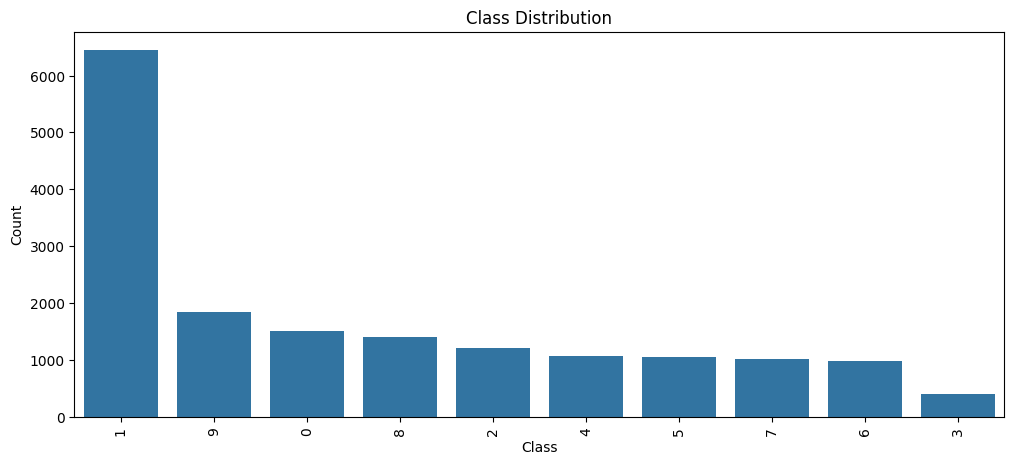

In [28]:
dist = class_distribution("/content/indianfood10-1")

df = pd.DataFrame(dist.items(), columns=["Class","Count"])

plt.figure(figsize=(12,5))

sns.barplot(data=df.sort_values("Count", ascending=False),
            x="Class",
            y="Count")

plt.xticks(rotation=90)

plt.title("Class Distribution")

plt.show()

## Bounding Box Size Distribution

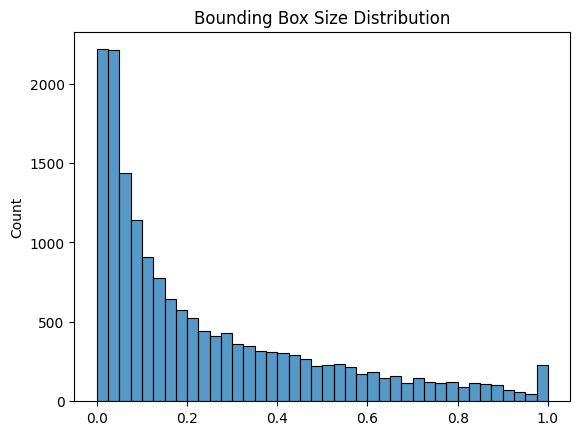

In [29]:
sizes = []

label_path = "/content/indianfood10-1/train/labels"

for file in os.listdir(label_path):

    with open(os.path.join(label_path,file)) as f:

        for line in f:

            _, _, _, w, h = map(float,line.split())

            sizes.append(w*h)

sns.histplot(sizes)

plt.title("Bounding Box Size Distribution")

plt.show()

## Summary of Findings

The exploratory analysis was conducted on three food detection datasets: IndianFood10, IndianFoodNet-30, and the South Indian Food Detection dataset. The purpose of this analysis was to understand the structure, annotation quality, and dataset suitability for training an object detection model.

• The IndianFood10 dataset contains a total of 16,922 bounding box annotations and serves as the primary detection dataset. The dataset is organized into train, validation, and test splits following the YOLO dataset format.

• The IndianFoodNet-30 dataset provides extended class coverage with 17,924 bounding box annotations across 30 food classes. This dataset increases the diversity of Indian food categories available for training.

• The South Indian Food Detection dataset contributes additional regional food categories with 6,438 annotated bounding boxes, improving the representation of South Indian dishes.

• Class distribution analysis indicates that certain food classes appear more frequently than others. This imbalance is expected in real-world food datasets and may require augmentation or balanced sampling during training.

• Bounding box density analysis shows that most images contain a small number of annotated food objects, typically between 1 and 5 objects per image. However, some images contain significantly higher object counts, indicating the presence of complex meal plates with multiple food items.

• Bounding box size distribution reveals that most detected objects occupy a relatively small portion of the image, with many bounding boxes having small normalized areas. This suggests that the detection model must handle small object detection effectively.

• Image resolution analysis confirms that the datasets have already been resized to approximately 640×640 pixels through the Roboflow preprocessing pipeline. This resolution is compatible with YOLO-based object detection models.

• Visual inspection of sample images confirms that the bounding box annotations correctly localize food items, indicating that the datasets are well-labeled and suitable for object detection tasks.

Overall, the datasets appear structurally consistent and suitable for training a YOLO-based food detection model. Combining these datasets increases the total number of training samples, expands the range of food classes, and improves the robustness of the detection model.

## Dataset Preparation Readiness

Based on the exploratory analysis, the datasets are suitable for ingestion into the training pipeline. The datasets follow the YOLO annotation format and contain sufficient diversity in terms of food classes, object counts, and object sizes. Minor preprocessing steps such as dataset consolidation, normalization, and augmentation will be applied before model training in the next stage.